In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
REPO_DIR = Path("..")
DATA_DIR = REPO_DIR / "Data"

X_train = pd.read_csv(DATA_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(DATA_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(DATA_DIR / "y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv", index_col=0).squeeze("columns")

In [5]:
pls_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pls', PLSRegression())
])

param_grid = {
    'pls__n_components': list(range(1,21))
}

pls_cv = GridSearchCV(
    pls_pipe,
    param_grid=param_grid,
    cv = 5,
    scoring="neg_root_mean_squared_error"
)

pls_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('pls', PLSRegression())]),
             param_grid={'pls__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12, 13, 14, 15, 16, 17, 18,
                                               19, 20]},
             scoring='neg_root_mean_squared_error')

#### Pipeline using Sklearn
`Sklearn` was using for all aspects of this pipeline and the pipeline itself. 
The `pipeline` function just turns the other sklearn functions into a function of steps. `SimpleImpter` finds missing values in dataset and fills that value with the median of the column. `StandardScalar` scales the unit variance of the model by removing the mean; also known as Z-score normalization. `PLSRegression` simply creates a PLS model that defaults to at least 2 parameters and 500 iterations. 

`GridsearchCV`utilizes multiple test combinations, coupled with cross-validation to ensuee model stability. It takes in an estimator (the model), a grid that has the number of compnents being tested, the number of folds, and the scoring metric. 

In [6]:
y_train_pred_pls = pls_cv.predict(X_train).ravel()
y_test_pred_pls = pls_cv.predict(X_test).ravel()

train_rmse_pls = np.sqrt(mean_squared_error(y_train, y_train_pred_pls))
test_rmse_pls = np.sqrt(mean_squared_error(y_test, y_test_pred_pls))

train_r2_pls = r2_score(y_train, y_train_pred_pls)
test_r2_pls = r2_score(y_test, y_test_pred_pls)

print("Best number of components:", pls_cv.best_params_['pls__n_components'])
print("Best CV RMSE:", -pls_cv.best_score_)
print("Train RMSE:", train_rmse_pls)
print("Test RMSE:", test_rmse_pls)
print("Train R^2:", train_r2_pls)
print("Test R^2:", test_r2_pls)

Best number of components: 15
Best CV RMSE: 0.1374200323428671
Train RMSE: 0.1284162915934566
Test RMSE: 0.1375227635789786
Train R^2: 0.6977372318380473
Test R^2: 0.6436090863345424


### Results
The best PLS model kept 15 latent components out of the candidates searched. That suggests the signal is not captured by just 1–3 dimensions; the model needed a fairly rich latent representation.

Test RMSE = 0.1375 means predictions are off by about 0.138 violent crimes per 100K population units, on average in root-mean-square terms. Since your target is scaled as a decimal proportion/rate rather than raw counts, that error should be interpreted relative to the range of the response.

Test R² = 0.6436 means the model explains about 64.4% of the variance in the outcome on the test set.

Compared with LASSO, PLS is very close but slightly worse on predictive performance in my current setup: a bit higher RMSE and a bit lower R².


PLS is working reasonably well. It shows that the predictors contain a lot of usable signal, and that some of that signal can be summarized through latent components. But, dimension reduction did not outperform sparse feature selection. LASSO still edges it out slightly, suggesting that the crime outcome may be better predicted by a selected subset of original variables than by compressing everything into latent factors. At the same time, the fact that PLS is so close to LASSO also suggests there is substantial correlation or overlap among predictors, because PLS can compress them and still retain most of the predictive information

In [7]:
print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("y_train mean:", y_train.mean())
print("y_train std:", y_train.std())

print("y_test min:", y_test.min())
print("y_test max:", y_test.max())
print("y_test mean:", y_test.mean())
print("y_test std:", y_test.std())

y_train min: 0.0
y_train max: 1.0
y_train mean: 0.24037013801756585
y_train std: 0.23364907560845655
y_test min: 0.0
y_test max: 1.0
y_test mean: 0.22844611528822056
y_test std: 0.23065145119506336


In [8]:
response_range = y_train.max() - y_train.min()
rmse = 0.1375

print("Response range:", response_range)
print("RMSE as % of range:", rmse / response_range)

Response range: 1.0
RMSE as % of range: 0.1375


### Residual Diagnostics

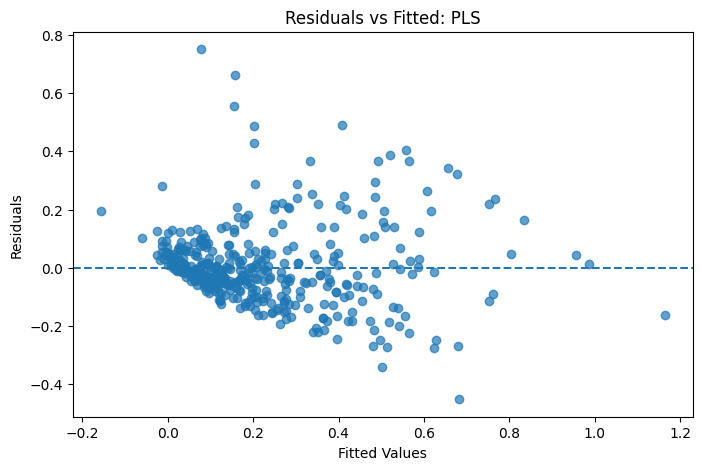

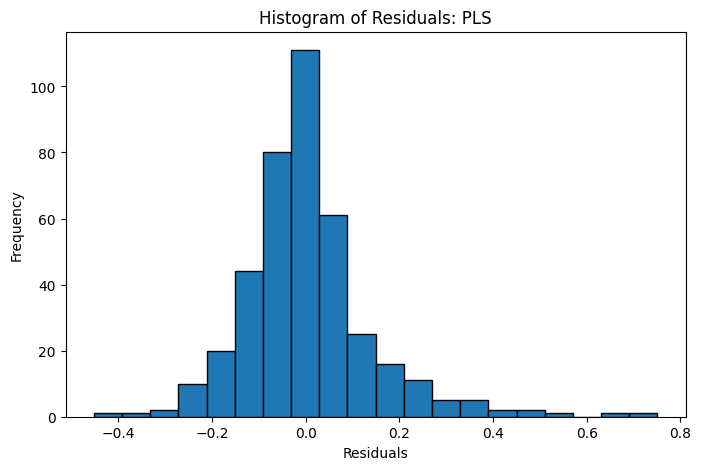

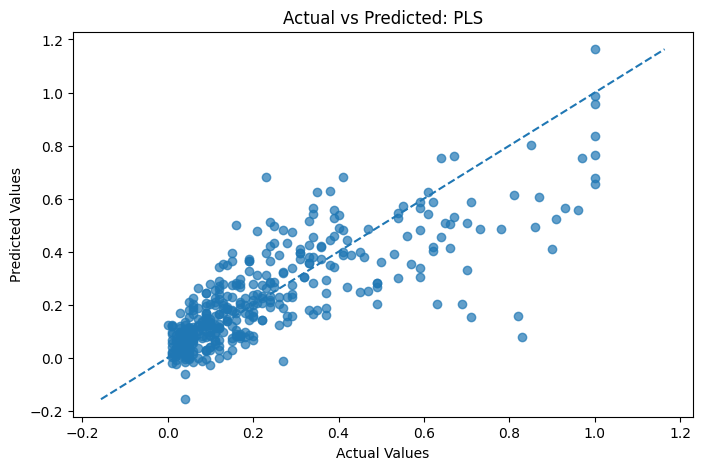

In [9]:
y_pred_pls = pls_cv.predict(X_test).ravel()
residuals_pls = y_test - y_pred_pls

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_pls, residuals_pls, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: PLS")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_pls, bins=20, edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals: PLS")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_pls, alpha=0.7)
lims = [min(y_test.min(), y_pred_pls.min()), max(y_test.max(), y_pred_pls.max())]
plt.plot(lims, lims, linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted: PLS")
plt.show()

All fairly normal looking, centered around zero, however each shows signs of heteroskedasiticity due to the high violent crime rate communties being harder to understand. 

### CV performance by number of components

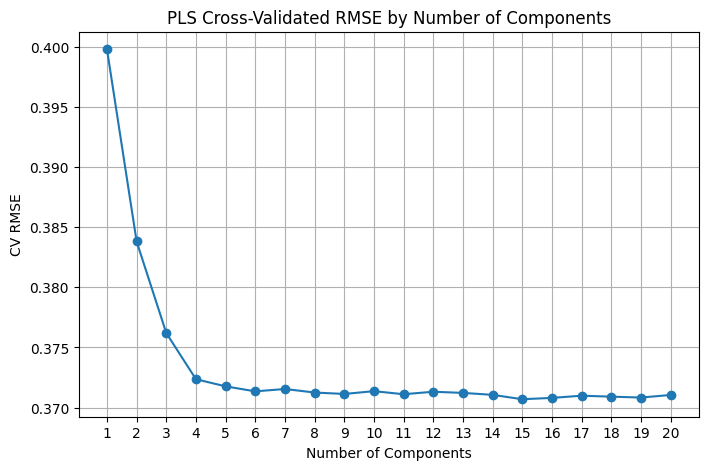

In [10]:
cv_results = pd.DataFrame(pls_cv.cv_results_)

components = cv_results["param_pls__n_components"].astype(int)
rmse_scores = np.sqrt(-cv_results["mean_test_score"])

plt.figure(figsize=(8, 5))
plt.plot(components, rmse_scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("CV RMSE")
plt.title("PLS Cross-Validated RMSE by Number of Components")
plt.xticks(components)
plt.grid(True)
plt.show()

Intial few components hold all the weight, then a plateu. The model is picking up on a group of very influential features, but isn't able to grasp the remaining complexity in violent crime rates. 

### PLS vs OLS vs LASSO

In [11]:
comparison = pd.DataFrame({
    "Model": ["OLS", "LASSO", "PLS"],
    "CV RMSE": [0.13619538508925447, 0.13619538508925447, -pls_cv.best_score_],
    "Test RMSE": [0.13855081681212486, 0.13676175913984734, test_rmse_pls],
    "Test R^2": [0.6382607600828487, 0.647542466585517, test_r2_pls]
})

comparison

,Model,CV RMSE,Test RMSE,Test R^2
0,OLS,0.136195,0.138551,0.638261
1,LASSO,0.136195,0.136762,0.647542
2,PLS,0.137420,0.137523,0.643609


All model performed nearly identical. The shrinkage power of LASSO is not being utilized, and PLS components are only capturing a central part features that can't explain the high crime communities. OLS would be a sufficient replacement, although they all suffer from heteroskedasticity. 